In [3]:
import pandas as pd
import numpy as np


df = pd.read_csv(r"/kaggle/input/weather-dataset/weatherHistory.csv")

df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True).dt.tz_localize(None)


df.set_index('Formatted Date', inplace=True)


df.sort_index(inplace=True)

df.head()


,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
Formatted Date,,,,,,,,,,,
2005-12-31 23:00:00,Partly Cloudy,rain,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,0.0,1016.66,Mostly cloudy throughout the day.
2006-01-01 00:00:00,Mostly Cloudy,rain,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,0.0,1016.15,Mostly cloudy throughout the day.
2006-01-01 01:00:00,Mostly Cloudy,rain,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,0.0,1015.87,Mostly cloudy throughout the day.
2006-01-01 02:00:00,Overcast,rain,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,0.0,1015.56,Mostly cloudy throughout the day.
2006-01-01 03:00:00,Mostly Cloudy,rain,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,0.0,1014.98,Mostly cloudy throughout the day.


In [4]:
print("dataset shape is ",df.shape)
print("********************************")
print(df.isnull().sum())

dataset shape is  (96453, 11)
********************************
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


The dataset contains **96,453 rows** and **11 columns**, which indicates a sufficiently large weather dataset for analysis and modeling.

Since only *Precip Type* has missing values, we can handle this later by:
- Filling with `"unknown"`  
- Forward/Backward fill  
-  Or dropping rows (not recommended unless necessary)****


In [59]:

df.dropna(subset=['Precip Type'], inplace=True)
print(df.isnull().sum())

Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


Earlier, we saw that the only column containing missing values was **`Precip Type`**,with 517 null entries.

### Approach
As the dataset is quite large rather then filling the null data ,we decided to drop null values rows.

```python
df.dropna(subset=['Precip Type'], inplace=True)


In [60]:
df["Precip Type"].unique()

array(['rain', 'snow'], dtype=object)

## 🌧️ Precipitation Type Analysis

After handling missing values, we examined the unique categories present in the **`Precip Type`** column.

```python
df["Precip Type"].unique()


In [ ]:
df["Daily Summary"].unique()

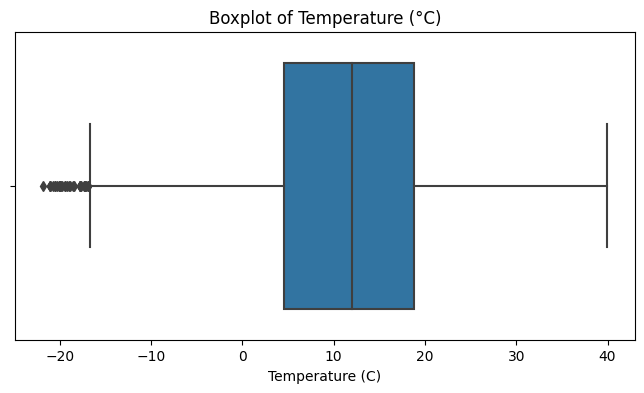

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df['Temperature (C)'])
plt.title("Boxplot of Temperature (°C)")
plt.show()


## 🌡️ Boxplot of Temperature (°C)

To detect outliers in the **Temperature (°C)** variable, we will use a boxplot.

### 🔍 Observations

- **Temperature values mostly range** between **0°C and 25°C**, indicating a generally cool-to-mild climate.
- **Outliers are present**, mainly on the lower end (around –20°C).  
  These likely represent:
  - Extremely cold days  
  - Rare events or sensor anomalies  
- The **median temperature** appears around **10–12°C**, showing that most readings fall in the cooler range.
- The whiskers extend up to about **40°C**, representing occasional warm or hot days.

### 📌 Interpretation
- The temperature distribution shows **seasonal variability**, which is expected in weather datasets.
- The outliers seem realistic and do not require removal unless they negatively impact model performance.
- This visualization is useful for understanding climate characteristics and guiding feature preprocessing decisions.

---



In [63]:
Q1 = df['Temperature (C)'].quantile(0.25)
Q3 = df['Temperature (C)'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_no_outliers = df[(df['Temperature (C)'] >= lower) & (df['Temperature (C)'] <= upper)]


In [64]:
df.shape

(95936, 11)

In [65]:
df['Summary'].unique()

array(['Partly Cloudy', 'Mostly Cloudy', 'Overcast', 'Foggy', 'Clear',
       'Breezy and Overcast', 'Breezy and Mostly Cloudy',
       'Windy and Overcast', 'Windy and Foggy', 'Breezy and Foggy',
       'Breezy and Partly Cloudy', 'Windy and Partly Cloudy',
       'Humid and Mostly Cloudy', 'Humid and Partly Cloudy', 'Breezy',
       'Windy and Mostly Cloudy', 'Dangerously Windy and Partly Cloudy',
       'Dry and Partly Cloudy', 'Dry', 'Windy', 'Humid and Overcast',
       'Breezy and Dry', 'Dry and Mostly Cloudy', 'Light Rain', 'Drizzle',
       'Windy and Dry', 'Rain'], dtype=object)

In [66]:

df.drop(['Daily Summary', 'Loud Cover'], axis=1, inplace=True)


In [67]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Summary"]=le.fit_transform(df["Summary"])
df["Precip Type"]=le.fit_transform(df["Precip Type"])

In [68]:
df.head()

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
Formatted Date,,,,,,,,,
2005-12-31 23:00:00,19,0,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,1016.66
2006-01-01 00:00:00,17,0,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,1016.15
2006-01-01 01:00:00,17,0,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,1015.87
2006-01-01 02:00:00,18,0,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,1015.56
2006-01-01 03:00:00,17,0,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,1014.98


In [69]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Apparent Temperature (C)', 
                'Humidity', 'Visibility (km)']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [70]:
df.head()

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
Formatted Date,,,,,,,,,
2005-12-31 23:00:00,19,0,0.577778,-1.391386,0.792748,17.1143,140.0,-0.091141,1016.66
2006-01-01 00:00:00,17,0,1.161111,-1.315706,0.588377,16.6152,139.0,-0.110429,1016.15
2006-01-01 01:00:00,17,0,1.666667,-1.307931,0.435100,20.2538,140.0,-0.110429,1015.87
2006-01-01 02:00:00,18,0,1.711111,-1.218257,0.435100,14.4900,140.0,-0.110429,1015.56
2006-01-01 03:00:00,17,0,1.183333,-1.269573,0.639470,13.9426,134.0,-0.110429,1014.98


Correlation of each feature with Temperature (C):
Temperature (C)             1.000000
Apparent Temperature (C)    0.992637
Visibility (km)             0.393719
Summary                     0.145821
Wind Bearing (degrees)      0.029937
Wind Speed (km/h)           0.008304
Pressure (millibars)       -0.005253
Precip Type                -0.563503
Humidity                   -0.632148
Name: Temperature (C), dtype: float64


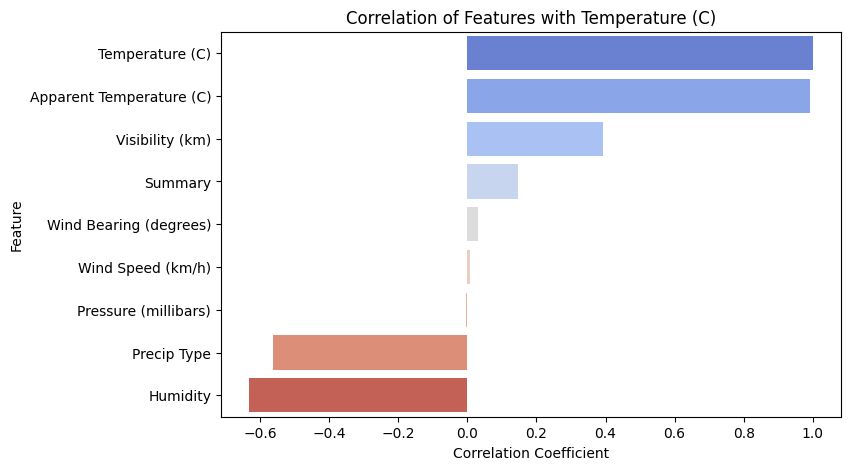

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = df.corr(numeric_only=True)
corr_with_temp = corr_matrix['Temperature (C)'].sort_values(ascending=False)

print("Correlation of each feature with Temperature (C):")
print(corr_with_temp)
plt.figure(figsize=(8,5))
sns.barplot(x=corr_with_temp.values, y=corr_with_temp.index, palette="coolwarm")
plt.title("Correlation of Features with Temperature (C)")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()


# ***we got negative relation in precip type and humidity. And we are droping [Wind Bearing (degrees),Wind Speed (km/h),Pressure (millibars)] as the have minimun co-relation with temp*** 


In [72]:
df.drop(['Wind Bearing (degrees)', 'Wind Speed (km/h)',"Pressure (millibars)"], axis=1, inplace=True)

In [73]:

df.head()

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Visibility (km)
Formatted Date,,,,,,
2005-12-31 23:00:00,19,0,0.577778,-1.391386,0.792748,-0.091141
2006-01-01 00:00:00,17,0,1.161111,-1.315706,0.588377,-0.110429
2006-01-01 01:00:00,17,0,1.666667,-1.307931,0.435100,-0.110429
2006-01-01 02:00:00,18,0,1.711111,-1.218257,0.435100,-0.110429
2006-01-01 03:00:00,17,0,1.183333,-1.269573,0.639470,-0.110429


In [74]:
import numpy as np

features = ['Summary', 'Precip Type','Apparent Temperature (C)', 'Humidity', 'Visibility (km)',
            ]
target = 'Temperature (C)'

data = df[features + [target]].values


In [75]:
time_steps = 60
X, y = [], []

for i in range(time_steps, len(data)):
    X.append(data[i-time_steps:i, :-1])  # previous 60 steps of features
    y.append(data[i, -1])                # temperature at current step

X, y = np.array(X), np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (95876, 60, 5)
y shape: (95876,)


In [76]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),c
    Dense(1)  # output: temperature
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,873 (999.50 KB)

 Trainable params: 255,873 (999.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    verbose=1
)


Epoch 1/25
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - loss: 27.7026 - mae: 3.4154 - val_loss: 1.6387 - val_mae: 0.9674
Epoch 2/25
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - loss: 4.2971 - mae: 1.5878 - val_loss: 1.6124 - val_mae: 0.9698
Epoch 3/25
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - loss: 3.4063 - mae: 1.4126 - val_loss: 1.9696 - val_mae: 1.1250
Epoch 4/25
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - loss: 2.7469 - mae: 1.2653 - val_loss: 2.6673 - val_mae: 1.2456
Epoch 5/25
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 2.4033 - mae: 1.1813 - val_loss: 2.3148 - val_mae: 1.1983
Epoch 6/25
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - loss: 2.2027 - mae: 1.1252 - val_loss: 3.2545 - val_mae: 1.3568
Epoch 7/25
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 2.0564 - mae: 1.0920 - val_loss: 2.5513 - val_mae: 1.1823
Epoch 8/25
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 37s 15ms/step - loss: 1.9924 - mae: 1.0673 - val_loss: 2.9211 - val_mae: 1.3030
Epoch 9/25
2397/2397 ━━

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("LSTM Training Progress")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [ ]:
dataset["Summary"].unique()

In [ ]:
import numpy as np


features = ['Summary', 'Precip Type', 'Apparent Temperature (C)', 'Humidity', 'Visibility (km)']
target = 'Temperature (C)'


case = np.array([0, 0, 28, 0.55, 12])   # Example: clear day, moderate humidity

# Your scaler was already fit on ['Apparent Temperature (C)', 'Humidity', 'Visibility (km)']
numeric_part = case[2:].reshape(1, -1)
scaled_numeric = scaler.transform(numeric_part)


scaled_case = np.hstack([case[:2].reshape(1, -1), scaled_numeric])

time_steps = 60   # same as used during training
X_input = np.repeat(scaled_case[np.newaxis, :, :], time_steps, axis=1)


y_pred_scaled = model.predict(X_input)


temp_mean = df['Temperature (C)'].mean()
temp_std = df['Temperature (C)'].std()
y_pred_real = y_pred_scaled * temp_std + temp_mean

print(f"🌤️ Custom Weather Input (encoded): {case}")
print(f"🌡️ Predicted Temperature: {y_pred_real[0][0]:.2f} °C")
